In [1]:
import pandas as pd
import numpy as np
from scipy import stats

# --- Load data ---
sensor_df = pd.read_csv('session_20260702_154930.csv')
phase_df = pd.read_csv('stimulus_session_20260702_160106.csv')

t0 = sensor_df['wallclock_ms'].iloc[0]
sensor_df['t_sec'] = (sensor_df['wallclock_ms'] - t0) / 1000
phase_df['t_sec'] = (phase_df['event_timestamp_ms'] - t0) / 1000

sensor_df['acc_mag'] = np.sqrt(
    sensor_df['acc_x']**2 + sensor_df['acc_y']**2 + sensor_df['acc_z']**2
)

# --- Build phase windows ---
phase_starts = phase_df[phase_df['event_type'] == 'phase_start'].reset_index(drop=True)
phase_windows = []
for i in range(len(phase_starts)):
    name = phase_starts.loc[i, 'phase_name']
    start = phase_starts.loc[i, 't_sec']
    end = (phase_starts.loc[i + 1, 't_sec'] if i + 1 < len(phase_starts)
           else phase_df[phase_df['event_type'] == 'session_end']['t_sec'].iloc[0])
    phase_windows.append((name, start, end))

print("Phase windows:")
for name, start, end in phase_windows:
    print(f"  {name:20s} {start:7.1f} -> {end:7.1f}  ({end-start:.0f}s)")

Phase windows:
  Pre-Video Rest         693.1 ->   813.3  (120s)
  Interesting Video      813.3 ->   993.7  (180s)
  Washout Rest           993.7 ->  1173.9  (180s)
  Boring Video          1173.9 ->  1354.1  (180s)
  Final Rest            1354.1 ->  1474.3  (120s)


In [2]:
# --- Artifact exclusion, same approach as your calibration sessions ---
# Compute threshold using only the session itself, skip first 30s settling
quiet_mask = sensor_df['t_sec'] >= (phase_windows[0][1] + 30)
quiet_data = sensor_df[quiet_mask]
acc_mean = quiet_data['acc_mag'].mean()
acc_std = quiet_data['acc_mag'].std()
threshold = acc_mean + 2 * acc_std

sensor_df['is_artifact_instant'] = sensor_df['acc_mag'] > threshold

# Expand flagged spikes to cover likely EDA decay tail (3s before, 15s after)
sensor_df['is_artifact'] = False
spike_times = sensor_df.loc[sensor_df['is_artifact_instant'], 't_sec'].values
for spike_t in spike_times:
    mask = (sensor_df['t_sec'] >= spike_t - 3) & (sensor_df['t_sec'] <= spike_t + 15)
    sensor_df.loc[mask, 'is_artifact'] = True

print(f"Threshold: {threshold:.4f}")
print(f"Total flagged (with decay window): {sensor_df['is_artifact'].sum()} "
      f"({100*sensor_df['is_artifact'].mean():.1f}%)")

Threshold: 9.8345
Total flagged (with decay window): 3373 (56.4%)


In [3]:
# --- Per-phase EDA stats, clean vs raw ---
results = []
for name, start, end in phase_windows:
    window = sensor_df[(sensor_df['t_sec'] >= start) & (sensor_df['t_sec'] < end)]
    clean = window[~window['is_artifact']]
    n_excluded = len(window) - len(clean)
    pct_excluded = 100 * n_excluded / len(window) if len(window) > 0 else 0

    slope = np.nan
    if len(clean) >= 2:
        slope, *_ = stats.linregress(clean['t_sec'], clean['eda_conductance_us'])

    results.append({
        'phase': name,
        'n_total': len(window),
        'pct_excluded': round(pct_excluded, 1),
        'eda_mean_raw': window['eda_conductance_us'].mean(),
        'eda_mean_clean': clean['eda_conductance_us'].mean() if len(clean) else np.nan,
        'eda_slope_clean': slope,
    })

results_df = pd.DataFrame(results)
pd.set_option('display.float_format', '{:.4f}'.format)
print(results_df.to_string(index=False))

            phase  n_total  pct_excluded  eda_mean_raw  eda_mean_clean  eda_slope_clean
   Pre-Video Rest      481       52.8000        0.3406          0.3357           0.0000
Interesting Video      722        7.8000        0.2593          0.2477          -0.0007
     Washout Rest      720       21.4000        0.2992          0.2883           0.0004
     Boring Video      721       31.3000        0.3029          0.3278          -0.0013
       Final Rest      481       76.1000        0.2468          0.2302          -0.0008


In [4]:
# --- Split Interesting Video into first half vs second half ---
# This directly checks your zone-out suspicion: if attention drifted partway
# through, EDA in the second half should look more like a rest/low-arousal
# phase than the first half does.
interesting_name, interesting_start, interesting_end = phase_windows[3]
midpoint = interesting_start + (interesting_end - interesting_start) / 2

first_half = sensor_df[(sensor_df['t_sec'] >= interesting_start) & 
                        (sensor_df['t_sec'] < midpoint)]
second_half = sensor_df[(sensor_df['t_sec'] >= midpoint) & 
                         (sensor_df['t_sec'] < interesting_end)]

first_clean = first_half[~first_half['is_artifact']]
second_clean = second_half[~second_half['is_artifact']]

print(f"Interesting Video -- first half:  mean={first_clean['eda_conductance_us'].mean():.4f}")
print(f"Interesting Video -- second half: mean={second_clean['eda_conductance_us'].mean():.4f}")

if len(first_clean) >= 2:
    slope1, *_ = stats.linregress(first_clean['t_sec'], first_clean['eda_conductance_us'])
    print(f"First half slope:  {slope1:.5f} /sec")
if len(second_clean) >= 2:
    slope2, *_ = stats.linregress(second_clean['t_sec'], second_clean['eda_conductance_us'])
    print(f"Second half slope: {slope2:.5f} /sec")

Interesting Video -- first half:  mean=0.3533
Interesting Video -- second half: mean=0.2591
First half slope:  -0.00223 /sec
Second half slope: -0.00043 /sec


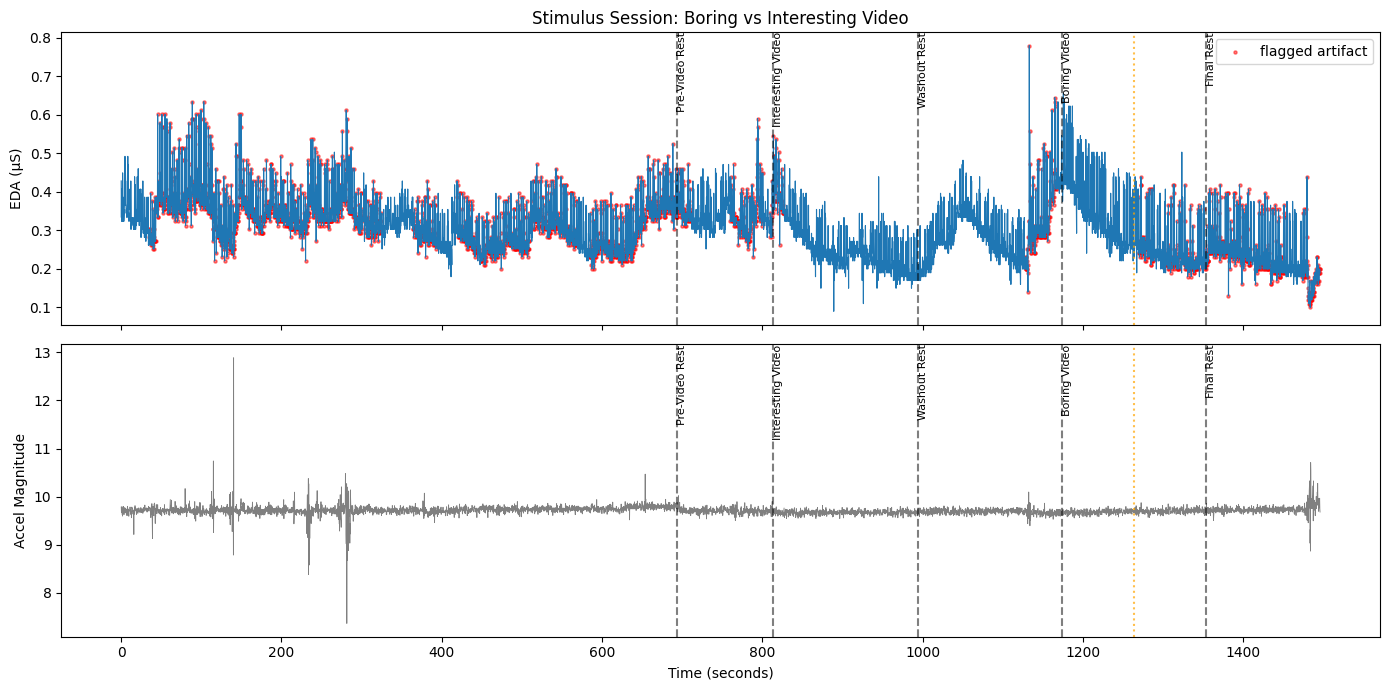

In [5]:
# --- Plot everything with phase boundaries, so you can visually spot 
#     where the itching and possible zone-out happened ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(sensor_df['t_sec'], sensor_df['eda_conductance_us'], linewidth=0.8)
axes[0].scatter(sensor_df.loc[sensor_df['is_artifact'], 't_sec'],
                 sensor_df.loc[sensor_df['is_artifact'], 'eda_conductance_us'],
                 color='red', s=5, alpha=0.5, label='flagged artifact')
axes[0].set_ylabel('EDA (µS)')
axes[0].legend(loc='upper right')
axes[0].set_title('Stimulus Session: Boring vs Interesting Video')

axes[1].plot(sensor_df['t_sec'], sensor_df['acc_mag'], linewidth=0.6, color='gray')
axes[1].set_ylabel('Accel Magnitude')
axes[1].set_xlabel('Time (seconds)')

for ax in axes:
    for name, start, end in phase_windows:
        ax.axvline(start, color='black', linestyle='--', alpha=0.5)
        ax.text(start, ax.get_ylim()[1], name, rotation=90, fontsize=8, va='top')
    # mark the interesting-video midpoint for the zone-out check
    ax.axvline(midpoint, color='orange', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [6]:
# --- First-half/second-half split for Boring Video, same method as Interesting ---
boring_name, boring_start, boring_end = phase_windows[1]  # index 1 = Boring Video
boring_midpoint = boring_start + (boring_end - boring_start) / 2

boring_first_half = sensor_df[(sensor_df['t_sec'] >= boring_start) & 
                               (sensor_df['t_sec'] < boring_midpoint)]
boring_second_half = sensor_df[(sensor_df['t_sec'] >= boring_midpoint) & 
                                (sensor_df['t_sec'] < boring_end)]

boring_first_clean = boring_first_half[~boring_first_half['is_artifact']]
boring_second_clean = boring_second_half[~boring_second_half['is_artifact']]

print(f"Boring Video -- first half:  mean={boring_first_clean['eda_conductance_us'].mean():.4f}")
print(f"Boring Video -- second half: mean={boring_second_clean['eda_conductance_us'].mean():.4f}")

if len(boring_first_clean) >= 2:
    slope1, *_ = stats.linregress(boring_first_clean['t_sec'], boring_first_clean['eda_conductance_us'])
    print(f"First half slope:  {slope1:.5f} /sec")
if len(boring_second_clean) >= 2:
    slope2, *_ = stats.linregress(boring_second_clean['t_sec'], boring_second_clean['eda_conductance_us'])
    print(f"Second half slope: {slope2:.5f} /sec")

Boring Video -- first half:  mean=0.2743
Boring Video -- second half: mean=0.2253
First half slope:  -0.00187 /sec
Second half slope: -0.00057 /sec


In [7]:
# --- Side-by-side comparison table, both videos ---
comparison = pd.DataFrame({
    'condition': ['Boring - 1st half', 'Boring - 2nd half', 
                  'Interesting - 1st half', 'Interesting - 2nd half'],
    'mean': [
        boring_first_clean['eda_conductance_us'].mean(),
        boring_second_clean['eda_conductance_us'].mean(),
        first_clean['eda_conductance_us'].mean(),
        second_clean['eda_conductance_us'].mean(),
    ]
})
print(comparison.to_string(index=False))

             condition   mean
     Boring - 1st half 0.2743
     Boring - 2nd half 0.2253
Interesting - 1st half 0.3533
Interesting - 2nd half 0.2591


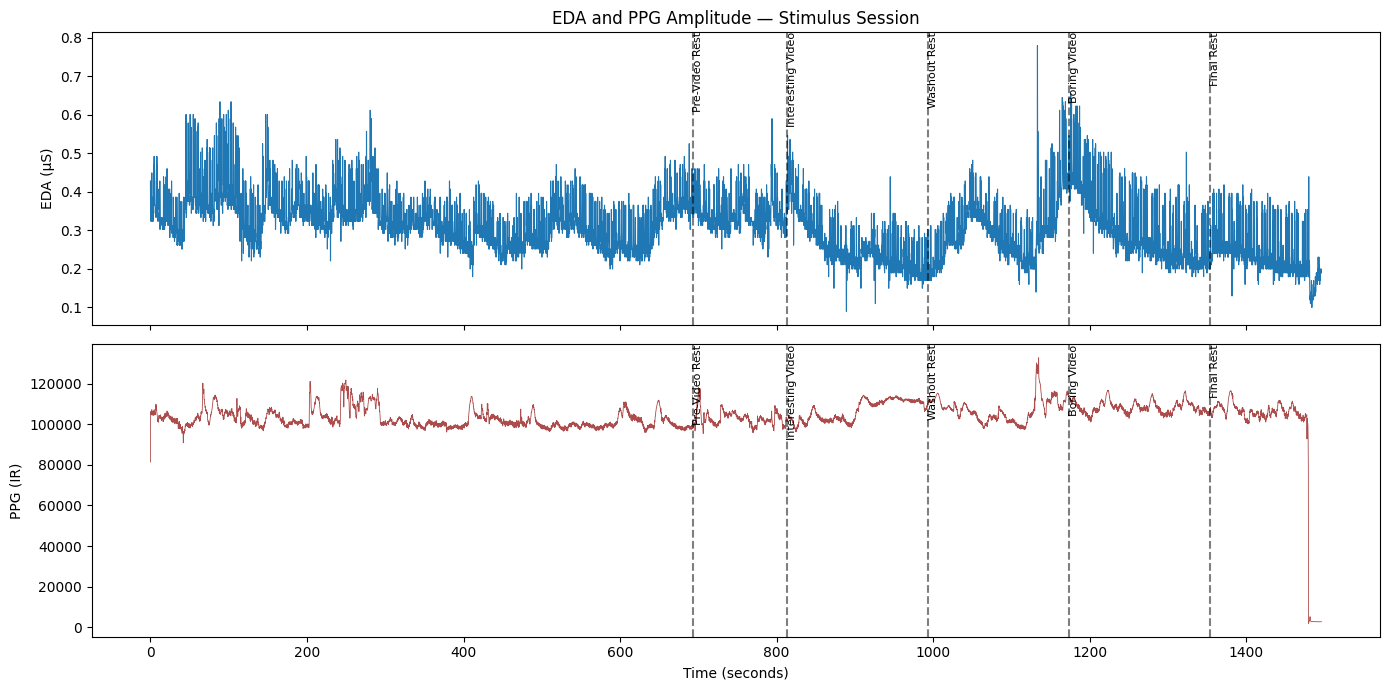

In [8]:
# --- Plot PPG alongside EDA with the same phase boundaries ---
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(sensor_df['t_sec'], sensor_df['eda_conductance_us'], linewidth=0.8)
axes[0].set_ylabel('EDA (µS)')
axes[0].set_title('EDA and PPG Amplitude — Stimulus Session')

axes[1].plot(sensor_df['t_sec'], sensor_df['ppg_ir'], linewidth=0.6, color='darkred', alpha=0.7)
axes[1].set_ylabel('PPG (IR)')
axes[1].set_xlabel('Time (seconds)')

for ax in axes:
    for name, start, end in phase_windows:
        ax.axvline(start, color='black', linestyle='--', alpha=0.5)
        ax.text(start, ax.get_ylim()[1], name, rotation=90, fontsize=8, va='top')

plt.tight_layout()
plt.show()

In [9]:
# --- Same first-half/second-half split, applied to PPG amplitude ---
def ppg_half_split(start, end, label):
    mid = start + (end - start) / 2
    first = sensor_df[(sensor_df['t_sec'] >= start) & (sensor_df['t_sec'] < mid)]
    second = sensor_df[(sensor_df['t_sec'] >= mid) & (sensor_df['t_sec'] < end)]
    first_c = first[~first['is_artifact']]
    second_c = second[~second['is_artifact']]
    print(f"{label} -- 1st half PPG mean: {first_c['ppg_ir'].mean():.0f}  std: {first_c['ppg_ir'].std():.1f}")
    print(f"{label} -- 2nd half PPG mean: {second_c['ppg_ir'].mean():.0f}  std: {second_c['ppg_ir'].std():.1f}")

ppg_half_split(phase_windows[1][1], phase_windows[1][2], "Boring")
ppg_half_split(phase_windows[3][1], phase_windows[3][2], "Interesting")

Boring -- 1st half PPG mean: 102486  std: 2289.9
Boring -- 2nd half PPG mean: 111322  std: 1608.6
Interesting -- 1st half PPG mean: 108495  std: 3115.0
Interesting -- 2nd half PPG mean: 107164  std: 2879.3
